In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import squidpy as sq

import os
import random 
np.random.seed(36)
random.seed(36)

In [2]:
# Check working directory
import os
os.getcwd()

'/homevol/huemail/G000428_MaiLa/analysis/Xenium314_setseed'

In [6]:
# Set working directory to where the files are
new_directory = "/homevol/huemail/G000428_MaiLa/20231101__013606__G000428_MaiLa_01112023_B1/output-XETG00068__0010614__Region_1__20231101__013739"
os.chdir(new_directory)

adata = sc.read_10x_h5("cell_feature_matrix.h5")
df = pd.read_csv("cells.csv")
df.set_index(adata.obs_names, inplace=True)
adata.obs = df.copy()
adata.obsm["spatial"] = adata.obs[["x_centroid", "y_centroid"]].copy().to_numpy()

# Calculating QC Metrics

In [7]:
sc.pp.calculate_qc_metrics(adata, percent_top=(10, 20, 50, 150), inplace=True)

In [8]:
cprobes = (
    adata.obs["control_probe_counts"].sum() / adata.obs["total_counts"].sum() * 100
)
cwords = (
    adata.obs["control_codeword_counts"].sum() / adata.obs["total_counts"].sum() * 100
)
print(f"Negative DNA probe count % : {cprobes}") # high % indicates non-specific probe binding
print(f"Negative decoding count % : {cwords}") # 

Negative DNA probe count % : 0.0046053315784127784
Negative decoding count % : 0.0026879603283753105


/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_in

<Axes: title={'center': 'Nucleus ratio'}, ylabel='Count'>

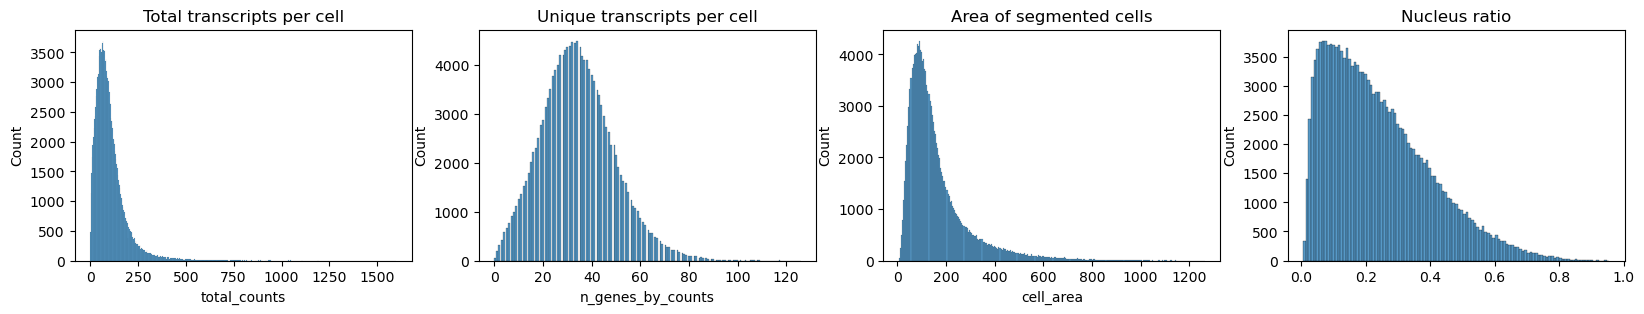

In [9]:
# Plotting QC metrics - again, also provided on the analysis_summary.html
fig, axs = plt.subplots(1, 4, figsize=(20, 3))

axs[0].set_title("Total transcripts per cell")
sns.histplot(
    adata.obs["total_counts"],
    kde=False,
    ax=axs[0],
)

axs[1].set_title("Unique transcripts per cell")
sns.histplot(
    adata.obs["n_genes_by_counts"],
    kde=False,
    ax=axs[1],
)


axs[2].set_title("Area of segmented cells")
sns.histplot(
    adata.obs["cell_area"],
    kde=False,
    ax=axs[2],
)

axs[3].set_title("Nucleus ratio")
sns.histplot(
    adata.obs["nucleus_area"] / adata.obs["cell_area"],
    kde=False,
    ax=axs[3],
)

/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


(0.0, 6000.0)

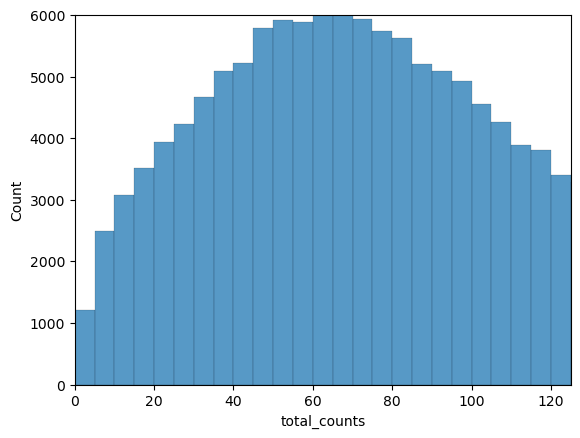

In [10]:
sns.histplot(
    adata.obs["total_counts"],
    kde=False,
    binwidth=5)
    #ax=axs[0],)

plt.xlim(0, 125)
plt.ylim(0, 6000)

In [11]:
# Filtering cells/genes 
sc.pp.filter_cells(adata, min_counts=10) 
sc.pp.filter_genes(adata, min_cells=5) 

In [12]:
adata

AnnData object with n_obs × n_vars = 155899 × 314
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    obsm: 'spatial'

In [13]:
# Normalisation using default setting
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)

# scale the data for visualisation step later
adata.layers['scaled'] = sc.pp.scale(adata, copy=True).X

# Dimentionality reduction
# PCA and UMAP
sc.pp.pca(adata, random_state=36) #default = 50PCs

In [14]:
sc.pp.neighbors(adata, n_neighbors =15, random_state=36) 
sc.tl.umap(adata, random_state=36)

/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/homevol/huemail/.local/lib/python3.9/site-packages/pynndescent/pynndescent_.py:346: NumbaPendingDeprecationWarning: Code using Numba extension API maybe depending on 'old_style' error-capturing, which is deprecated and will be replaced by 'new_style' in a future release. See details at https://numba.readthedocs.io/en/latest/reference/deprecation.html#deprecation-of-old-style-numba-captured-errors
Exception origin:
  File "/homevol/huemail/.local/lib/python3.9/site-packages/numba/core/types/functions.py", line 486, in __getnewargs__
    raise ReferenceError("underlying object has vanished")

  init_rp_tree(data, dist, current_graph, leaf_array)
/homevol/huemail/.local/lib/python3.9/site-packages/pynndescent/py

In [15]:
# Clustering by leiden, using different resolutions
sc.tl.leiden(adata, resolution = 2.0, key_added = "leiden_2.0", random_state=36)

/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1207: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(values):
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1216: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


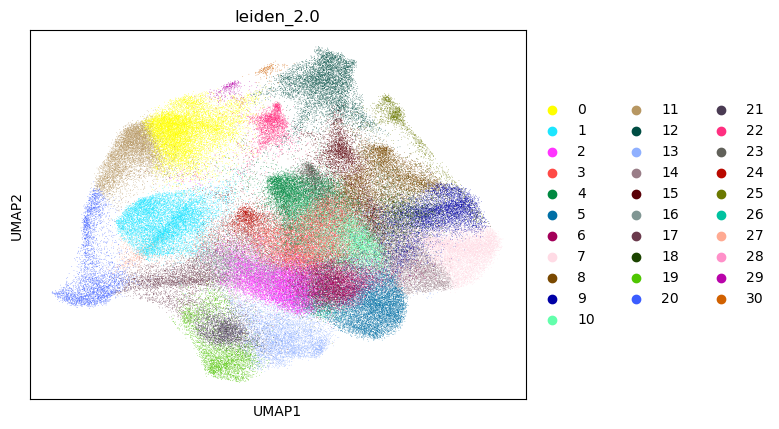

In [16]:
sc.pl.umap(adata, color=['leiden_2.0'])

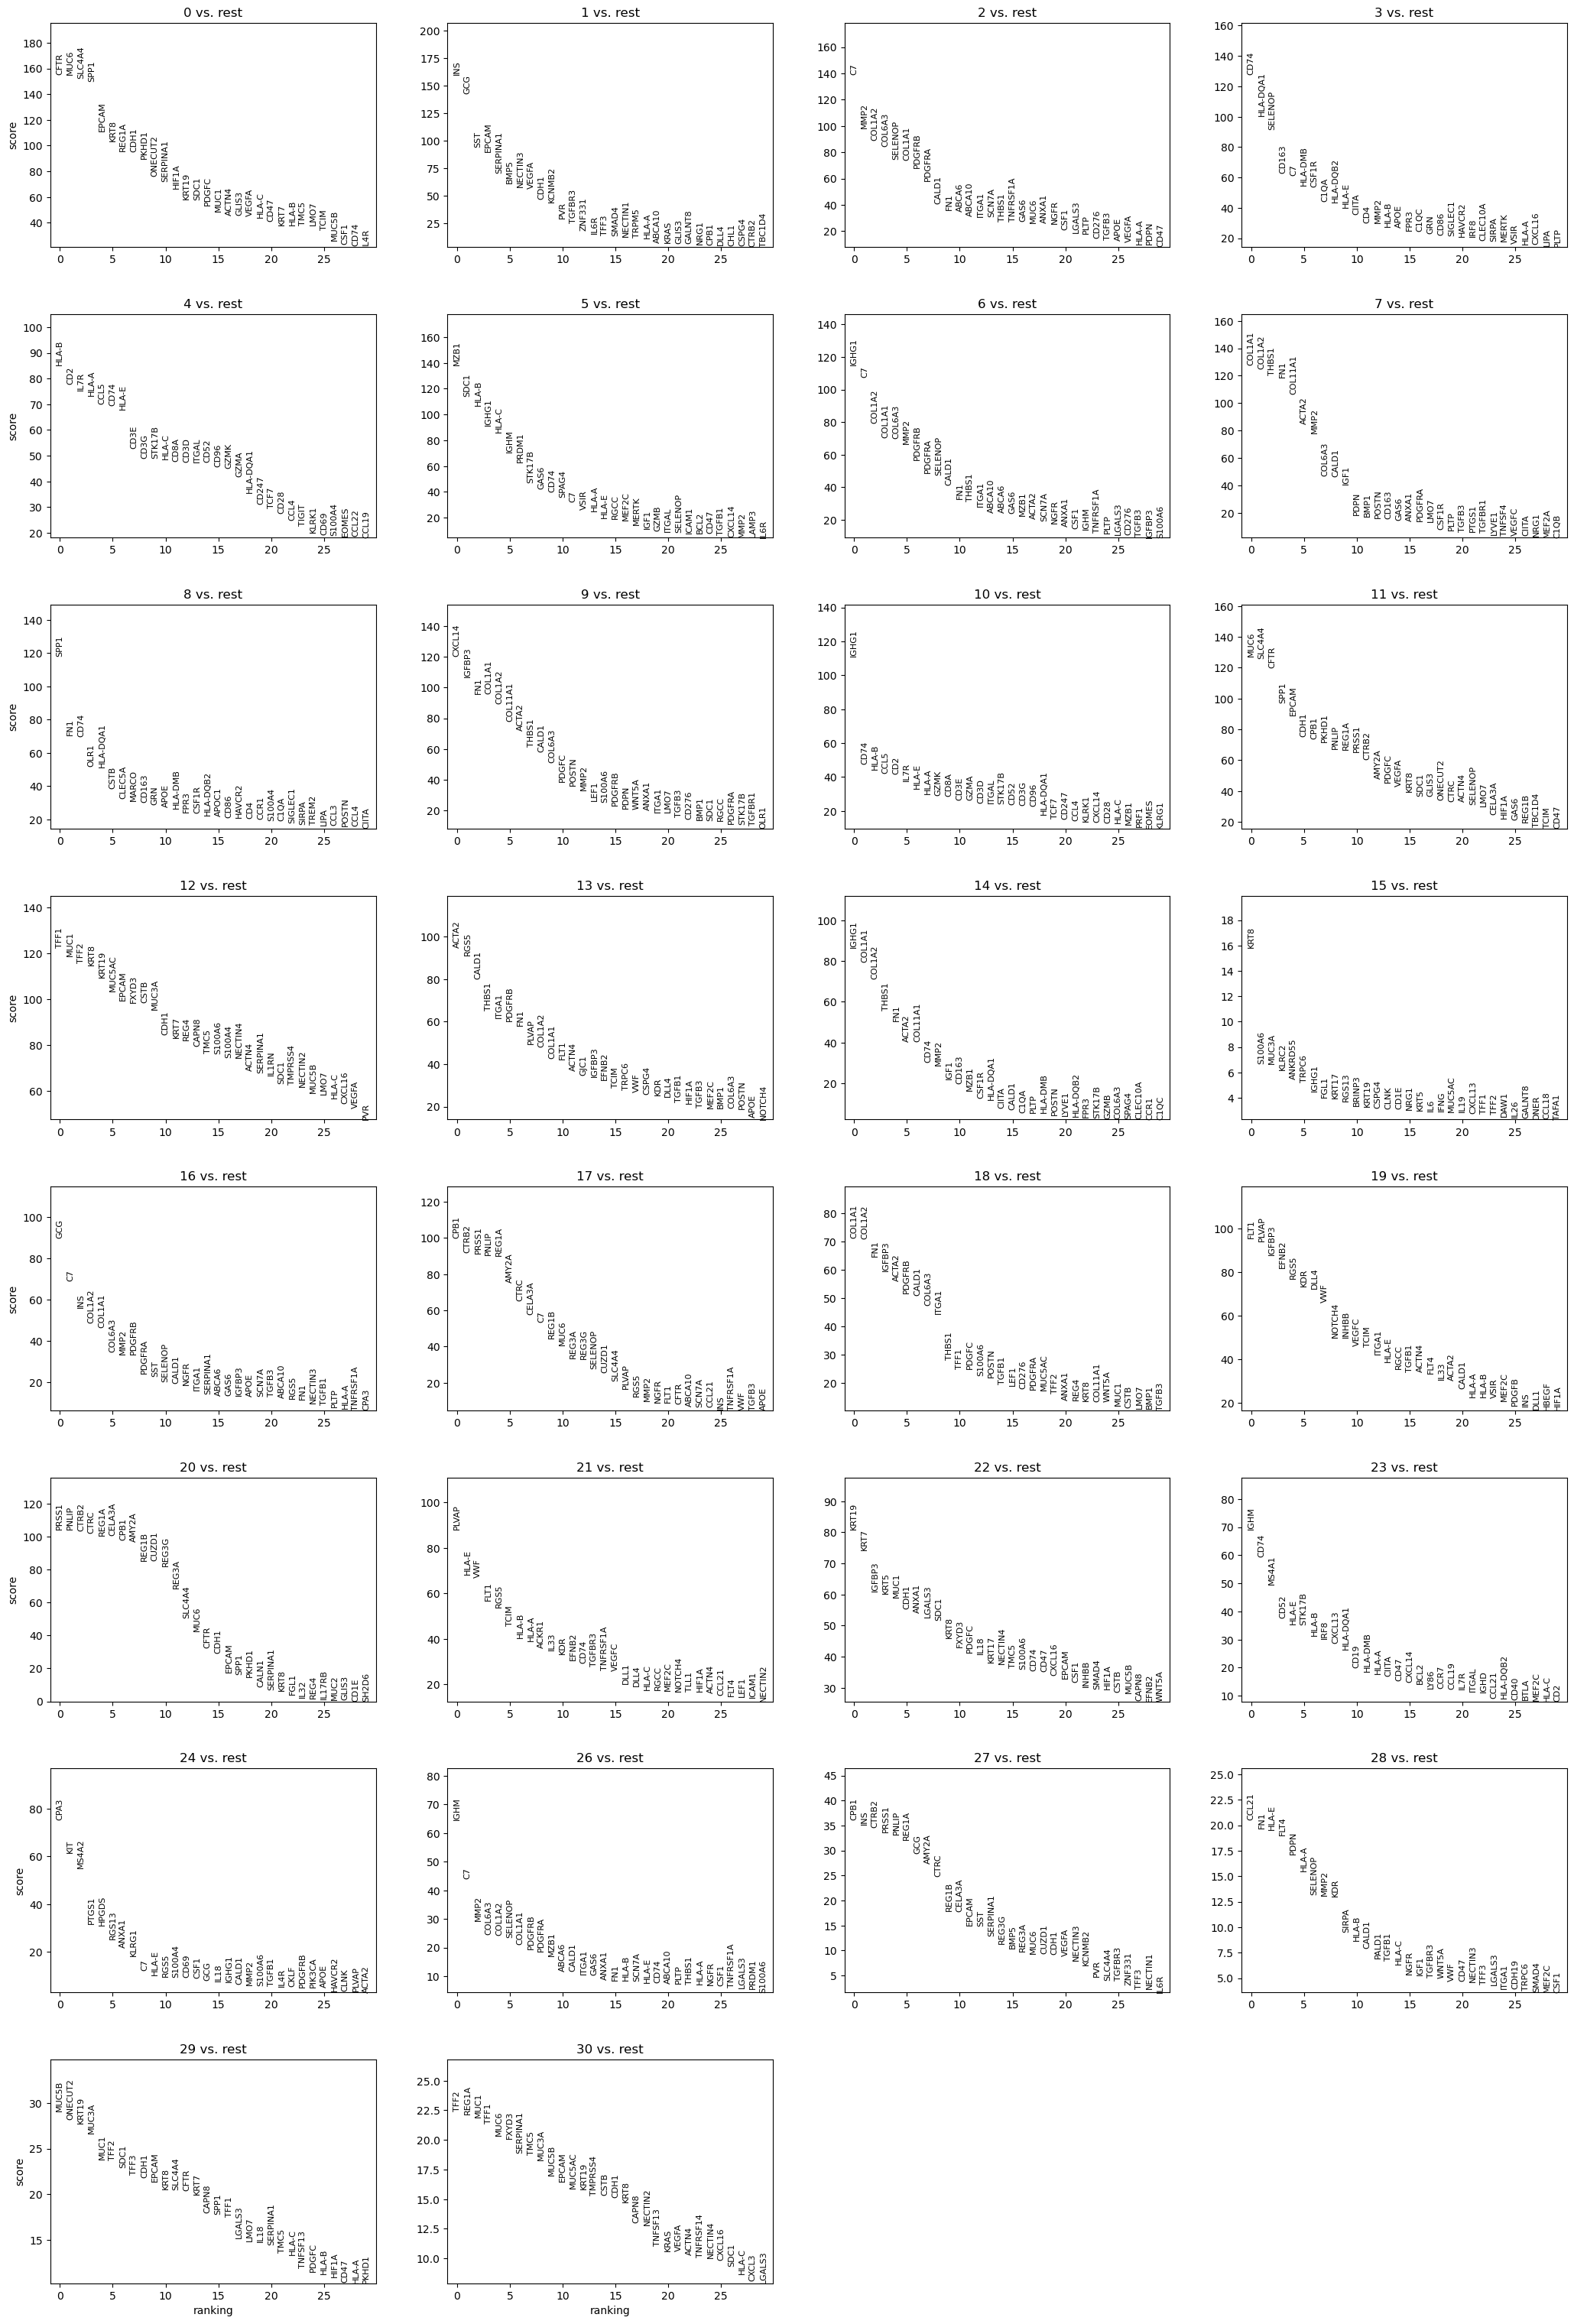

In [51]:
# Find Marker genes
sc.tl.rank_genes_groups(adata, 'leiden_2.0', method='wilcoxon')
sc.pl.rank_genes_groups(adata, n_genes=30, sharey=False)

/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/tools/_dendrogram.py:105: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(adata.obs[group]):
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/tools/_dendrogram.py:133: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_df = rep_df.groupby(level=0).mean()


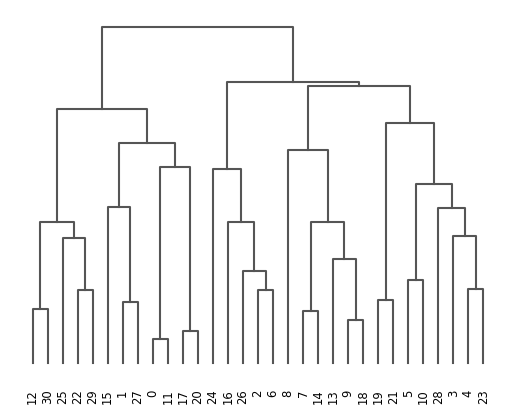

<Axes: >

In [18]:
# Running dendogram
sc.tl.dendrogram(adata, groupby = "leiden_2.0")
sc.pl.dendrogram(adata, groupby = "leiden_2.0")

In [19]:
cluster_anno = {
    "0": "Ductal",
    "1": "Endocrine", 
    "2": "CAFs_NRT", 
    "3": "TAMs_C1QC", 
    "4": "T cells", 
    "5": "Plasma", 
    "6": "CAFs_NRT", 
    "7": "CAFs_MYO", 
    "8": "TAMs_SPP1_OLR1", 
    "9": "CAFs_CXCL14", 
    "10": "T cells", 
    "11": "Ductal",
    "12": "Malignant cells", 
    "13": "vSMCs",
    "14": "CAFs_MYO", 
    "15": "Unassigned",
    "16": "Endocrine", 
    "17": "Acinar",
    "18": "CAFs_MYO", 
    "19": "Endothelial",
    "20": "Acinar_REG", 
    "21": "Endothelial",
    "22": "Malignant cells", 
    "23": "B cells", 
    "24": "Mast", 
    "25": "Malignant cells", 
    "26": "Mixed_Plasma_CAFs_NRT", 
    "27": "Mixed_Acinar_Endocrine", 
    "28": "LECs", 
    "29": "Ductal_MUC5B",
    "30": "Malignant cells" 
    }

In [20]:
adata.obs["anno"] = adata.obs['leiden_2.0'].map(cluster_anno)
adata.obs['leiden_2.0'].map(cluster_anno)

aaaagpjp-1           CAFs_MYO
aaaajjem-1         Unassigned
aaaakjpn-1            T cells
aaaaodjn-1             Plasma
aaabdbmm-1            T cells
                   ...       
oifpnggh-1    Malignant cells
oigahbdm-1           CAFs_MYO
oigaknom-1             Acinar
oigbbegl-1           CAFs_MYO
oigbdjgg-1           CAFs_MYO
Name: leiden_2.0, Length: 155899, dtype: object

/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1207: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(values):
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1216: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1207: FutureWarning: is_categorical_dtype 

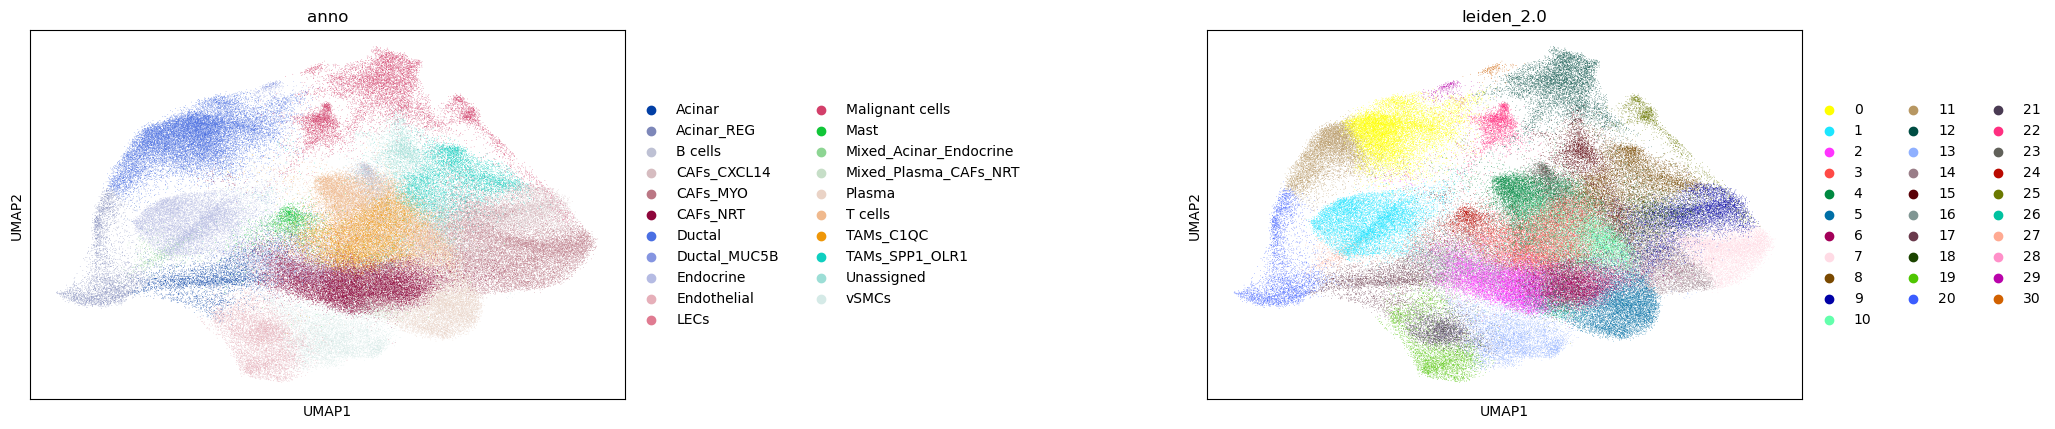

In [21]:
sc.pl.umap(adata, color=["anno", "leiden_2.0"], wspace = 0.8)

/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:747: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if c is not None and c in adata.obs and is_categorical_dtype(adata.obs[c]):
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:471: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(color_source_vector):
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:483: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_map)
/homevol/huemail/.local/lib/python3.9/site-pa

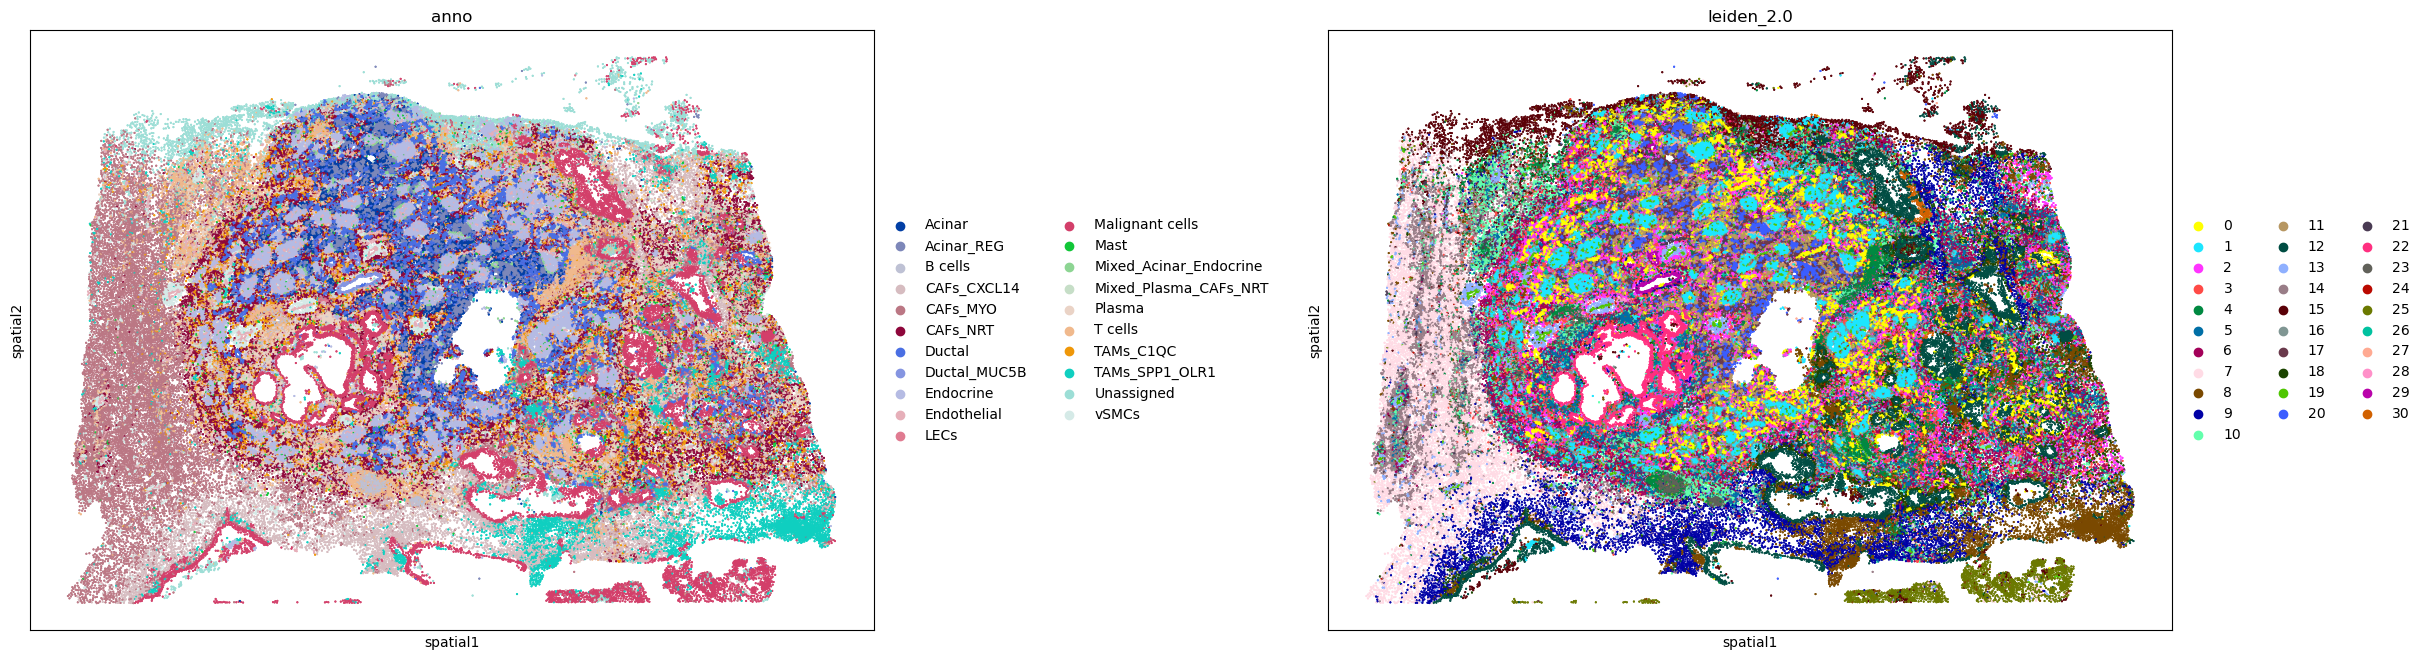

In [22]:
# Visualisation - at spatial context
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    shape=None,
    color=[
       "anno" ,"leiden_2.0"
    ],
    wspace=0.4,
    size=1,
    figsize = (10,10)
)

In [23]:
clusters_to_exclude = ['25']  # from another sample
mask_to_keep = ~adata.obs['leiden_2.0'].isin(clusters_to_exclude)
adata_filtered = adata[mask_to_keep, :].copy()

In [25]:
adata = adata_filtered # to remove the cluster

In [28]:
# Used Xenium Explorere to confirm those cells not present
gene_sets= {
    'Malignant cells': ['KRT19','KRT7','KRT5','FXYD3','MUC5AC'],
    'Ductal MUC5B': ['MUC5B','ONECUT2'], 
    'Ductal' : ['CFTR','SLC4A4','MUC6'],
    'Acinar' : ['CPB1','CTRB2','PRSS1'],
    'Acinar_REG+' : ['REG1B','REG3G','REG3A'],
    'Tuft' : ['AVIL','TRPM5','BMX','RGS13','SH2D6',"POU2F3"],
    'Endocrine': ['INS','GCG','SST'],
    # Lymphoid stroma 
    'FRCs': {'PLA2G2A','PDPN','IGF1'},
    'TRCs': {"CCL19","PDGFRA","ICAM1"},
    'LECs': {'LYVE1','FLT4','PDPN','CCL21'},
    # Stromal
    'Endothelial' : ['VWF','PLVAP','FLT1'],
    'SMCs' : ['RGS5','CSPG4','THBS1','ACTA2'],
    'Pericytes': ['PDGFRB','RGS5'],
    'Schwann': ['CDH19','CHL1','NGFR'], 
    # CAFs
    'CAFs_MYO': ['COL11A1','PDGFC'],
    'CAFs_CXCL14': ['COL11A1','CXCL14'],
    'CAFs_NRT' : ['PDGFRA','SCN7A','C7','ABCA6','ABCA10'],
    # Lymphoid
    'NK': {'GNLY', 'NKG7','KLRC1'},
    'CD4 T cells': ['IL7R','CD4','TCF7'],
    'CD4 Treg' : {'FOXP3','IKZF2','CCR8'},
    'CD4 Tfh' : ['CD4','ICOS','CD40LG'], 
    'CD8 T cells': ['CD8A','CD8B','GZMB','GZMA'],
    'CD8 TRM' : ['CD8A','CD8B','ITGAE','ITGA1'], 
    'B cells': ['MS4A1','CD52','CD19'],
    'Plasma': ['MZB1'],
    # Myeloid
    'DC1' : ['CLEC9A','IRF8','IDO1'],
    'DC2' : ['CLEC10A','CD1C'],
    'Migratory DCs' : ['CCL22','LAMP3'],
    'Mast' :['CPA3','KIT','TPSAB1'],
    'TAMs_SPP1' : ['MARCO','GRN','APOE','SPP1'],
    'TAMs_OLR1' : ['OLR1','HBEGF'],
    'TAMs_C1QC' : ['C1QC','SELENOP','C1QA','F13A1','SLC40A1'],
    'TAMs_MHC' : ['CD86','HLA-DRB1','HLA-DRB5','CSF1R']
}
    
for cell_type, genes in gene_sets.items():
    sc.tl.score_genes(adata, gene_list=genes, score_name=f"{cell_type}_score")

In [36]:
# Extract all module score columns from adata.obs
score_columns = [f"{ct}_score" for ct in gene_sets.keys() if f"{ct}_score" in adata.obs.columns]
score_data = adata.obs[score_columns]

In [37]:
#Instead of assigning every cell, we only classify if the highest score is above a quantile-based threshold:
# Get the highest score per cell
adata.obs["max_score"] = adata.obs[score_columns].max(axis=1)
adata.obs["cell_class_threshold"] = adata.obs[score_columns].idxmax(axis=1)
adata.obs["cell_class_threshold"] = adata.obs["cell_class_threshold"].str.replace("_score", "")

# Apply a minimum threshold (e.g., 80th percentile)
threshold = score_data.quantile(0.75) 
adata.obs.loc[adata.obs["max_score"] < threshold.max(), "cell_class_threshold"] = "Unclassified"

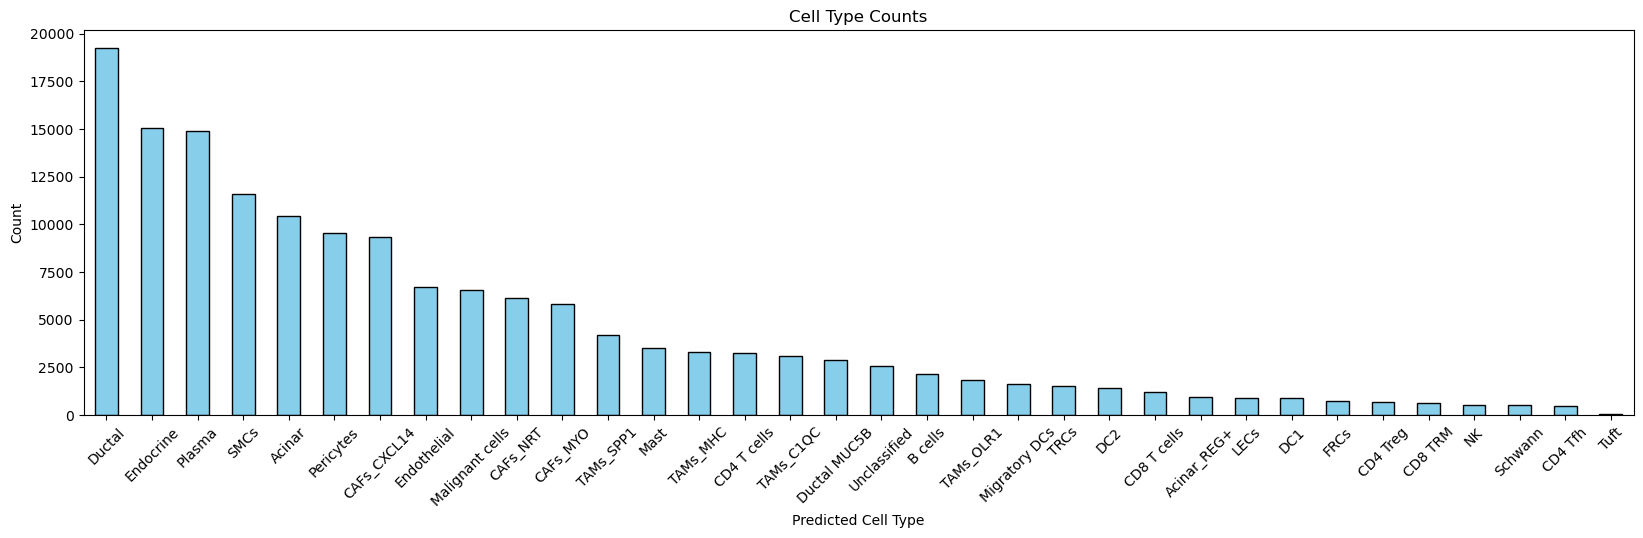

In [38]:
import matplotlib.pyplot as plt

# Count each predicted cell type
cell_type_counts = adata.obs["cell_class_threshold"].value_counts()

# Plot bar chart
plt.figure(figsize=(20, 5))
cell_type_counts.plot(kind="bar", color="skyblue", edgecolor="black")

# Customize labels
plt.xlabel("Predicted Cell Type")
plt.ylabel("Count")
plt.title("Cell Type Counts")
plt.xticks(rotation=45)  # Rotate labels for readability

plt.show()

In [40]:
mask = adata.obs['cell_class_threshold'] == 'SMCs'

adata.obs.loc[mask, 'cell_class_threshold'] = adata.obs.loc[mask, 'anno'].map({
    'vSMCs': 'SMCs',        # keep as SMCs
    'CAFs_MYO': 'CAFs_MYO'  # reassign to CAFs_MYO
}).fillna('SMCs')  

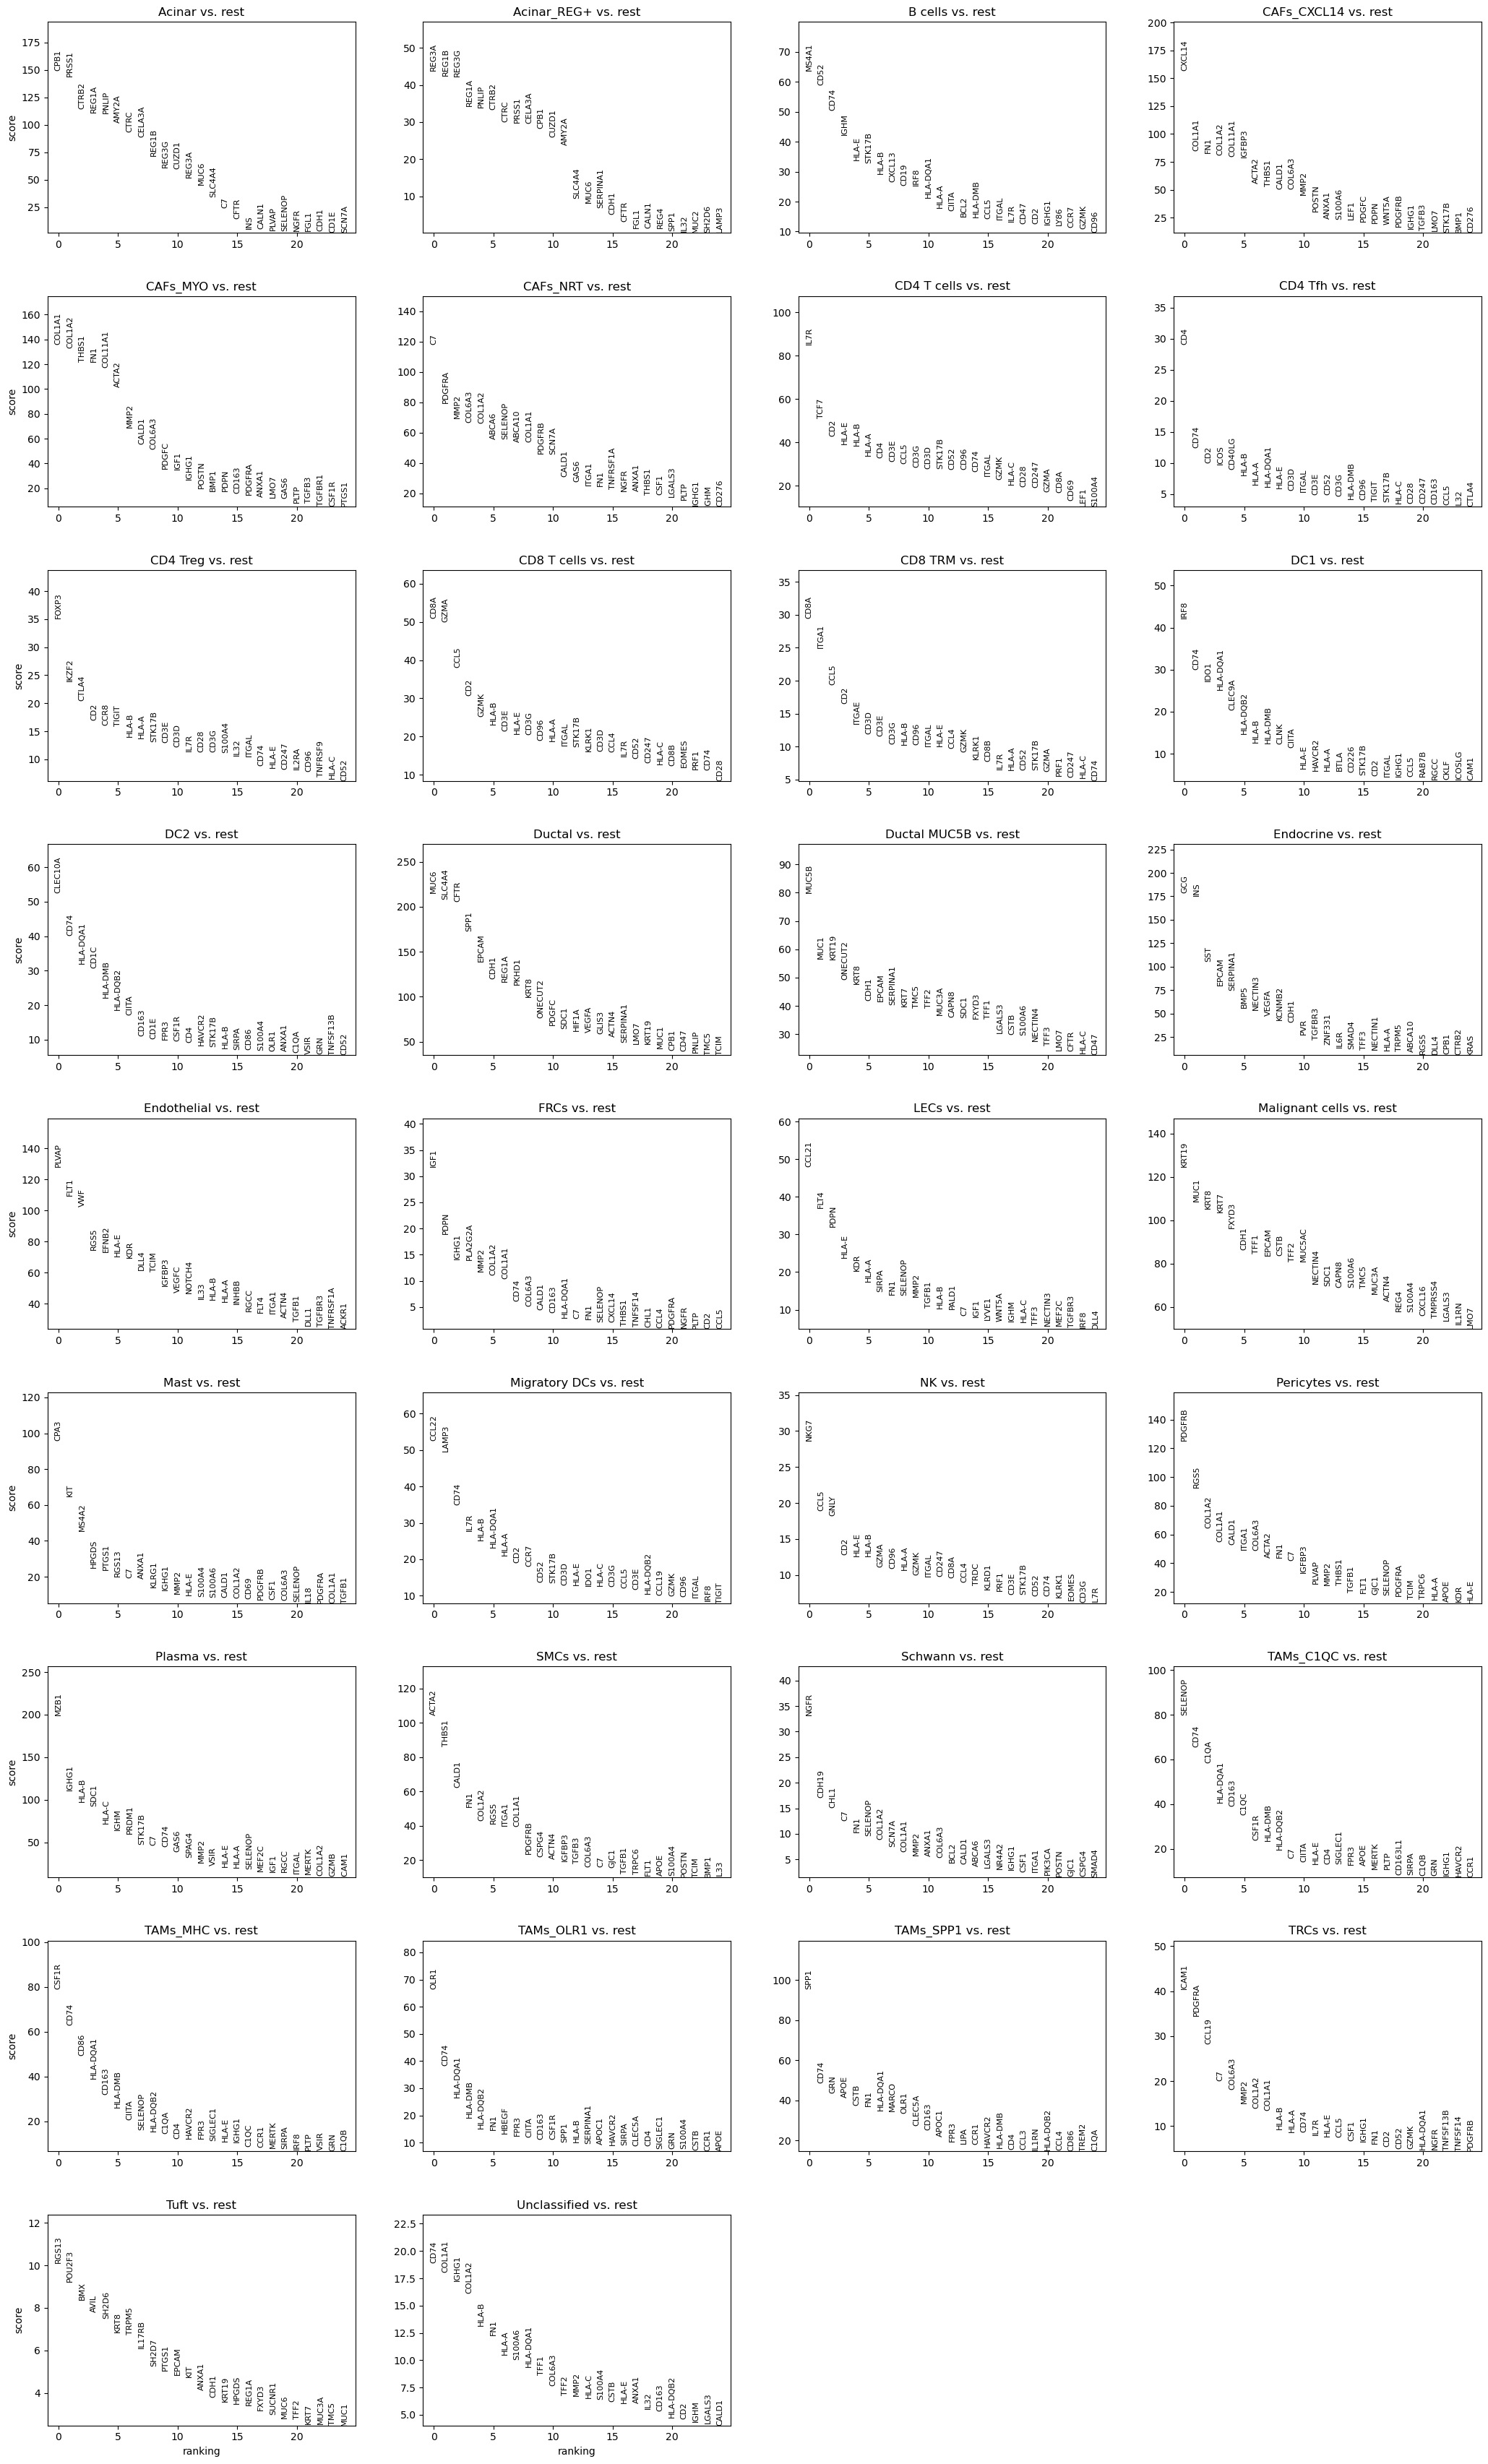

In [55]:
# Find Marker genes to verify identity
sc.tl.rank_genes_groups(adata, 'cell_class_threshold', method='wilcoxon')
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False) 

/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/tools/_dendrogram.py:105: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(adata.obs[group]):
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/tools/_dendrogram.py:133: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_df = rep_df.groupby(level=0).mean()


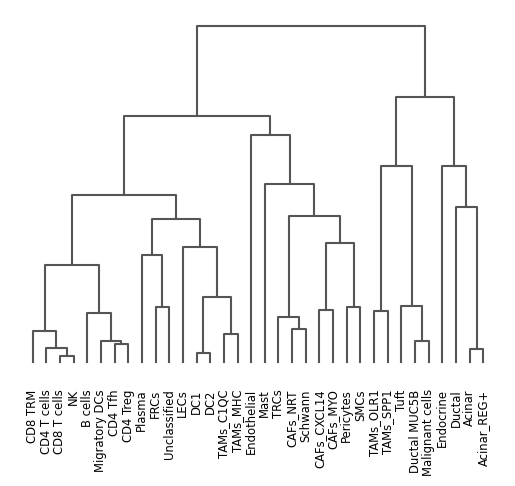

<Axes: >

In [56]:
# Running dendogram
sc.tl.dendrogram(adata, groupby = "cell_class_threshold")
sc.pl.dendrogram(adata, groupby = "cell_class_threshold")

In [57]:
# USING THE SAME SET OF GENES in snRNA-seq
genes_anno = ['CD8A','ITGAE','ITGA1', 'IL7R','TCF7','CD4',
              'GZMA','GZMK','GNLY','NKG7','MS4A1','CD52','CD19',
              'LAMP3','CCL22','CXCL13','ICOS','CD40LG',
              'FOXP3','IKZF2','CTLA4','TIGIT','MZB1','IGHG1',
              'PLA2G2A','IGF1','PDPN','CCL21','FLT4',
              'CLEC9A','IRF8','IDO1','CLEC10A','CD1C',
              'C1QA','SELENOP','C1QC','HLA-DMB','CSF1R','CD86','HLA-DQA1','PLVAP','VWF','FLT1',
              'CPA3','KIT','MS4A2','ICAM1','CCL19','PDGFRA','C7','SCN7A','ABCA6','ABCA10',
              'CDH19','CHL1','NGFR','CXCL14','COL11A1','PDGFC','PDGFRB','RGS5',
              'ACTA2','CALD1','OLR1','SPP1','GRN','APOE','MARCO',
              'POU2F3','RGS13','BMX','AVIL','MUC5B','ONECUT2','SLC4A4','KRT19','MUC1','KRT8','KRT7','FXYD3',
              'INS','GCG','SST','CFTR','SLC4A4','MUC6','AMY2A','CTRC','PRSS1','CUZD1','REG3A','REG3G','REG1B']

/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:748: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


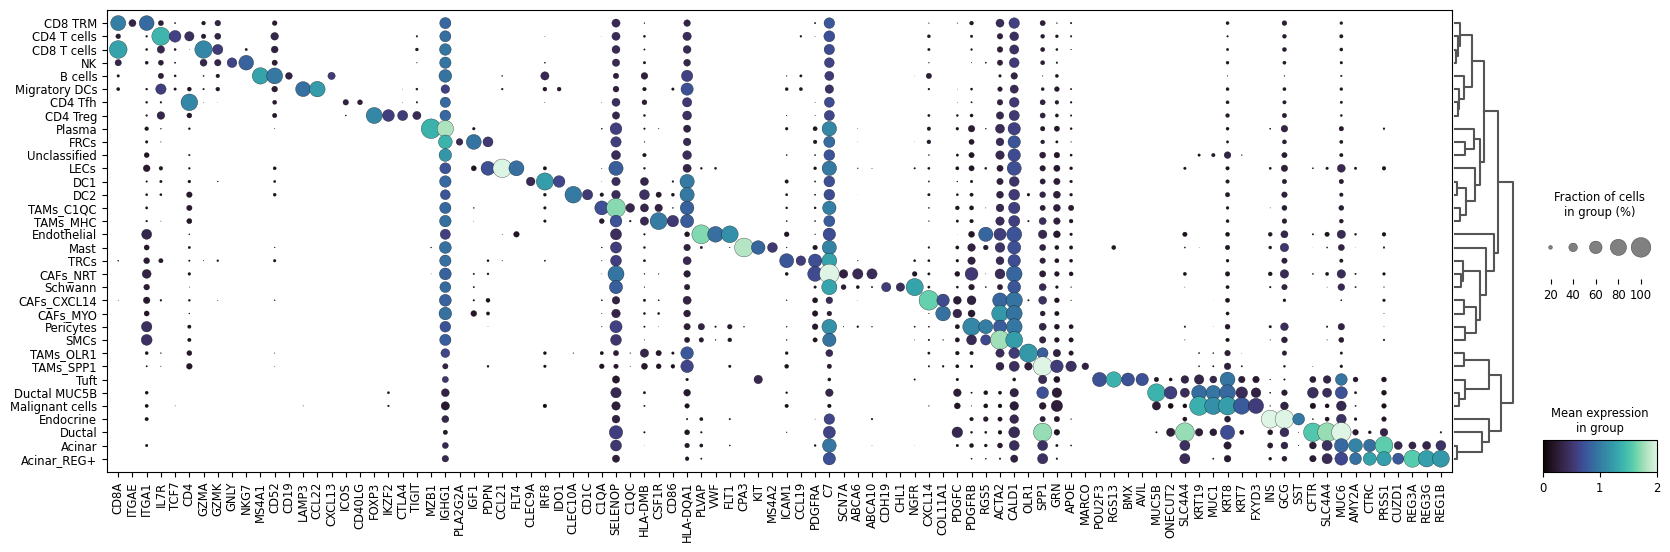

In [58]:
sc.pl.dotplot(adata, var_names = genes_anno , groupby='cell_class_threshold',
             figsize=(20, 6), vmax=2, vmin = 0, dot_min=0.1, cmap = 'mako',
              #save="SupFig_annoMH065.pdf",
             dendrogram=True)

# Neighbourhood enrichment analysis using a defined radius of 50 micrometers

In [60]:
sq.gr.spatial_neighbors(adata, coord_type="generic", spatial_key="spatial", radius=50) 
sq.gr.nhood_enrichment(adata, cluster_key="cell_class_threshold", seed=112233)

/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/gr/_utils.py:141: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(adata.obs[key]):
100%|█████████████████████████████████████████| 1000/1000 [00:50<00:00, 19.74/s]


/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/gr/_utils.py:141: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(adata.obs[key]):
/homevol/huemail/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/gr/_utils.py:141: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(adata.obs[key]):
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_utils.py:556: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, u

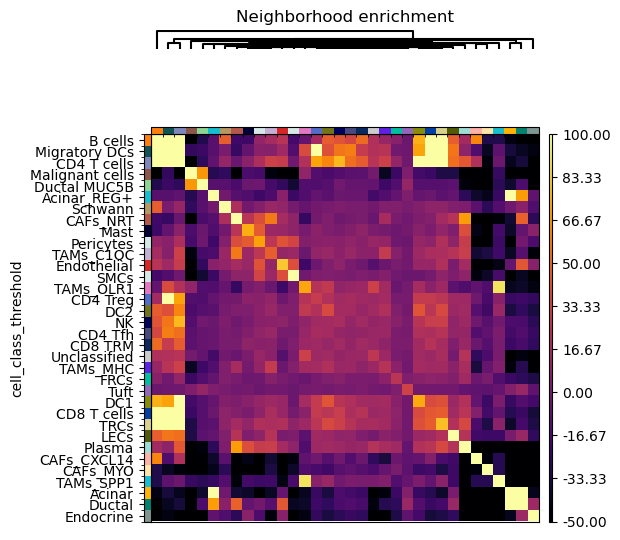

In [82]:
sq.pl.nhood_enrichment(
    adata,
    cluster_key="cell_class_threshold",
    method="average",
    cmap="inferno",
    vmin=-50, #(-50)
    vmax=100, # (100) for whole sections
    figsize=(5, 5),
)

# Compute Moran's I score: to determine spatially variable genes

In [62]:
sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True)
sq.gr.spatial_autocorr(
    adata,
    mode="moran",
    n_perms=100,
    n_jobs=1,
)

100%|███████████████████████████████████████████| 100/100 [00:28<00:00,  3.50/s]


In [65]:
adata.uns["moranI"].head(10)

,I,pval_norm,var_norm,pval_z_sim,pval_sim,var_sim,pval_norm_fdr_bh,pval_z_sim_fdr_bh,pval_sim_fdr_bh
INS,0.805720,0.0,0.000002,0.0,0.009901,0.000004,0.0,0.0,0.010061
TFF1,0.757328,0.0,0.000002,0.0,0.009901,0.000005,0.0,0.0,0.010061
GCG,0.747793,0.0,0.000002,0.0,0.009901,0.000005,0.0,0.0,0.010061
MUC6,0.731514,0.0,0.000002,0.0,0.009901,0.000005,0.0,0.0,0.010061
IGHG1,0.719966,0.0,0.000002,0.0,0.009901,0.000005,0.0,0.0,0.010061
TFF2,0.716713,0.0,0.000002,0.0,0.009901,0.000005,0.0,0.0,0.010061
MUC5AC,0.689099,0.0,0.000002,0.0,0.009901,0.000005,0.0,0.0,0.010061
SST,0.674667,0.0,0.000002,0.0,0.009901,0.000004,0.0,0.0,0.010061
SLC4A4,0.650488,0.0,0.000002,0.0,0.009901,0.000004,0.0,0.0,0.010061
REG4,0.650261,0.0,0.000002,0.0,0.009901,0.000005,0.0,0.0,0.010061


In [80]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Row-wise proportions (each row sums to 1)
prop_table = pd.crosstab(
    adata.obs["anno"],
    adata.obs["cell_class_threshold"],
    normalize='index'
)

# Convert to percentage
prop_table_percent = prop_table * 100

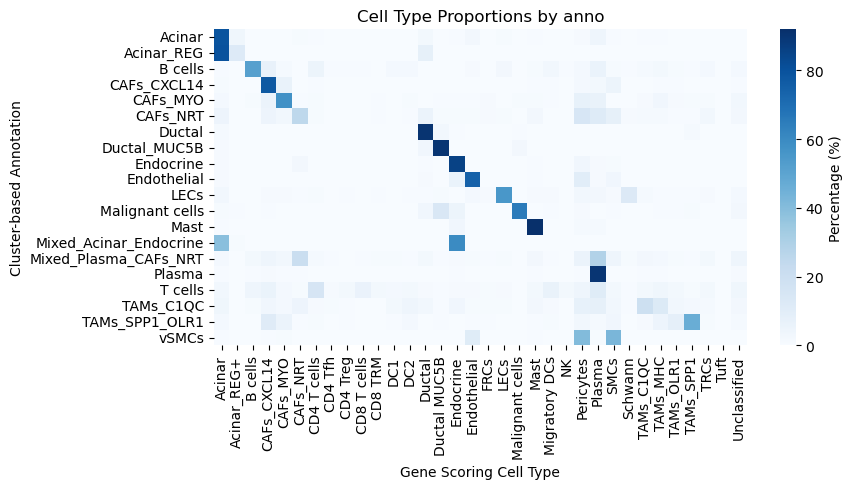

In [81]:
plt.figure(figsize=(9, 5))
sns.heatmap(
    prop_table_percent,
    #annot=True, fmt=".1f", 
    annot=False,  # disables cell text
    cmap="Blues",
    cbar_kws={'label': 'Percentage (%)'}
)
plt.title("Cell Type Proportions by anno")
plt.xlabel("Gene Scoring Cell Type")
plt.ylabel("Cluster-based Annotation")
plt.tight_layout()
plt.show() # After updating anno cluster

# Representative visualizations

In [68]:
#DEFINE BROAD CELL CLASS
subset_to_broad = {
    'Acinar': 'Acinar',
    'Acinar_REG':'Acinar',
    'B cells':  'B cells',
    'CAFs_CXCL14':'CAFs',
    'CAFs_MYO': 'CAFs',
    'CAFs_NRT': "CAFs",
    "Ductal": 'Ductal',
    "Ductal_MUC5B":'Ductal',
    "Endocrine": 'Endocrine',
    "Endothelial":'Endothelial',
    "LECs": "Endothelial",
    "Malignant cells": 'PDAC',
    "Mast": 'Mast',
    'Mixed_Acinar_Endocrine' : "Acinar",
    "Mixed_Plasma_CAFs_NRT" : "Plasma",
    "Plasma":  'Plasma',
    "T cells": "T/NK cells",
    "TAMs_C1QC":'TAMs',
    "TAMs_SPP1_OLR1": "TAMs",
    "Unassigned" : "Unassigned",
    "vSMCs" : "Pericytes_vSMCs"
}

In [69]:
adata.obs["broad_cell_class"] = (
        adata.obs["anno"]
        .map(subset_to_broad)
        .fillna("Other")  
    )

In [70]:
adata.uns['broad_cell_class_colors'] = ['#ff7f0e', '#aa40fc', '#d5eae7','#279e68','#e377c2','#d62728',
                                        '#ff9896','#8c564b','#c5b0d5','#98df8a','#023fa5','#17becf',"#cccccc"]

/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1207: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(values):
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1216: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


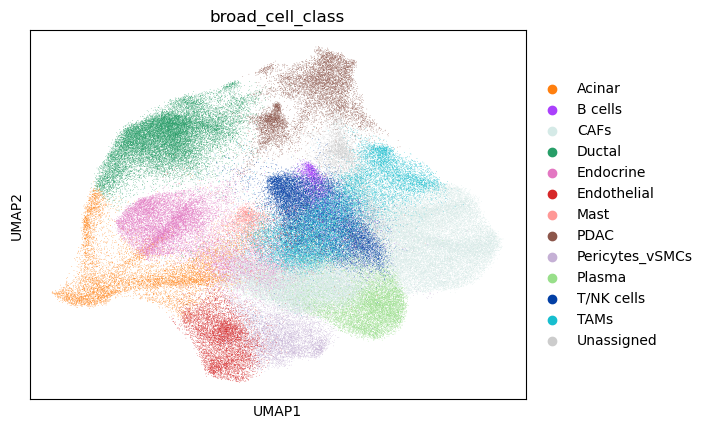

In [71]:
sc.pl.umap(adata, color=['broad_cell_class'], #save='Fig1C_MH065_UMAP.pdf'
          )

/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:747: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if c is not None and c in adata.obs and is_categorical_dtype(adata.obs[c]):
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:471: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(color_source_vector):
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:483: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_map)
/homevol/huemail/.local/lib/python3.9/site-pa

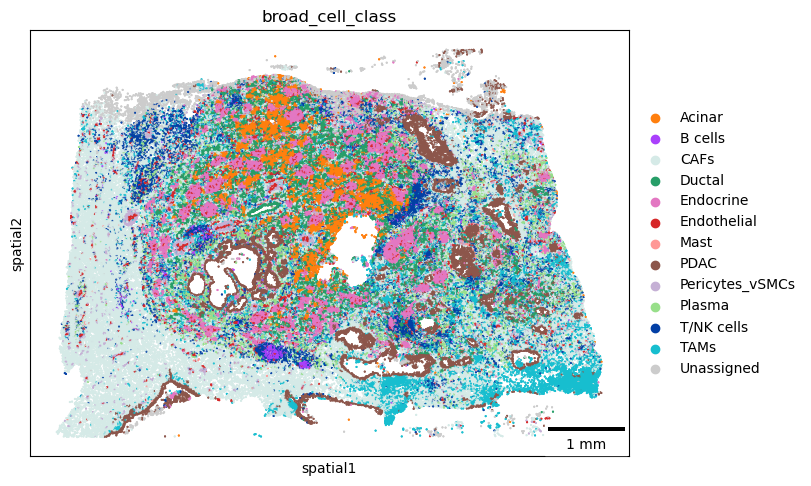

In [73]:
# Visualisation - at spatial context
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    shape=None,
    color=[
       "broad_cell_class",
    ],
    #crop_coord=[(0, 250, 8000, 4600)],
    scalebar_dx = 1.0,
    scalebar_kwargs={"scale_loc": "bottom", "location": "lower right"},
    size=1,
    img=False,
    figsize=(8,8),
    #save='Fig1C_spatial_MH065.pdf'
)

In [74]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Row-wise proportions (each row sums to 1)
prop_table = pd.crosstab(
    adata.obs["broad_cell_class"],
    adata.obs["cell_class_threshold"],
    normalize='index'
)

# Convert to percentage
prop_table_percent = prop_table * 100

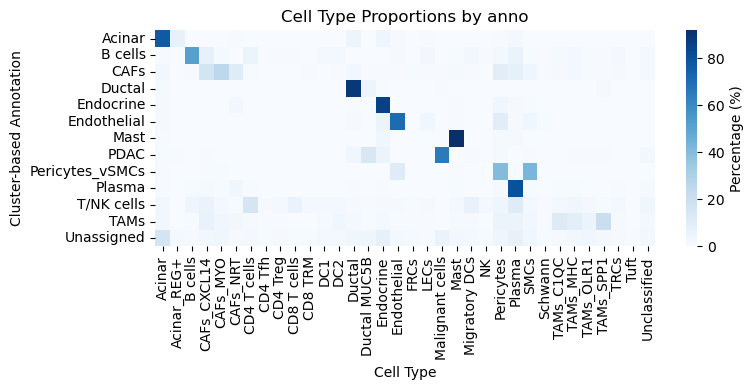

In [75]:
plt.figure(figsize=(8, 4))
sns.heatmap(
    prop_table_percent,
    #annot=True, fmt=".1f", 
    annot=False,  # disables cell text
    cmap="Blues",
    cbar_kws={'label': 'Percentage (%)'}
)
plt.title("Cell Type Proportions by anno")
plt.xlabel("Cell Type")
plt.ylabel("Cluster-based Annotation")
plt.tight_layout()
plt.savefig("SupFig_broad_cell_class_vs_genescoring.pdf", dpi=300, bbox_inches='tight')
plt.show() # After updating anno cluster

In [77]:
genes_anno = ['KRT19','KRT7','MUC1','TFF1','TFF2',
              'MUC5B','MUC6','ONECUT2',#'CALN1','SERPINA1','MUC3A',
              'CFTR', 'SLC4A4', 
              'REG3G','REG3A', #"REG1B",
              'AMY2A','CPB1','CTRC','CELA3A',
              'PDGFRB','RGS5','GJC1','TRPC6',
             'CALD1','COL1A1','FN1','COL6A3','COL11A1',
             'GCG','SST','INS',
              'VWF','PLVAP','KDR',#'FLT4',#'CCL21',
              'MS4A1','CD19','IGHM',
              'IGHG1','MZB1',
              'CD3D', 'CD3E','CD96','CD2',
             'CPA3','MS4A2', 'KIT',
              'CD163','CSF1R','SIGLEC1',
             ]

order = [
    'PDAC', 'Ductal', 'Acinar', 'Pericytes_vSMCs',
    'CAFs', 'Endocrine', 'Endothelial', 'B cells', 'Plasma',
    'T/NK cells', 'Mast', 'TAMs']

# Ensure categorical dtype and remove "Unassigned"
adata = adata[adata.obs['broad_cell_class'] != 'Unassigned', :].copy()
adata.obs['broad_cell_class'] = adata.obs['broad_cell_class'].astype('category')

# Reorder categories to match your custom order
adata.obs['broad_cell_class'] = adata.obs['broad_cell_class'].cat.set_categories(order, ordered=True)

/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_matrixplot.py:143: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  values_df = self.obs_tidy.groupby(level=0).mean()


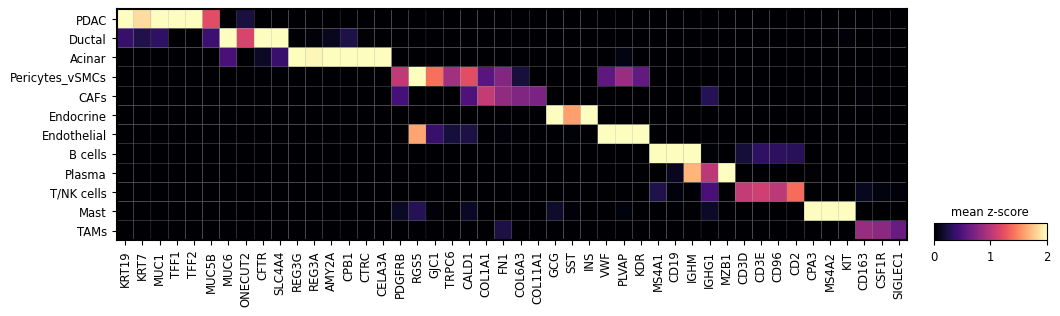

In [78]:
# Plot and save matrixplot
sc.pl.matrixplot(
    adata,
    genes_anno,
    groupby='broad_cell_class',
    categories_order=order,
    colorbar_title='mean z-score',
    layer='scaled',
    vmin=0, vmax=2,
    cmap='magma',
    figsize=(12, 3),
    #save='SupFig_heatmap.pdf'  # saves to 'figures/Fig1_heatmap.pdf' by default
)